# Parameter estimation for an LG-SSM using SGD and MCMC

*This example is adapted from the dynamax notebooks [MAP parameter estimation for an LG-SSM using EM and SGD](https://probml.github.io/dynamax/notebooks/linear_gaussian_ssm/lgssm_learning.html) and [Bayesian parameter estimation for an LG-SSM using HMC](https://probml.github.io/dynamax/notebooks/linear_gaussian_ssm/lgssm_hmc.html).*

This notebook shows how to "fit" a linear Gaussian SSM &mdash; i.e., estimate the parameters &mdash; using either stochastic gradient descent (SGD) on the negative log marginal likelihood, or Markov chain Monte Carlo (MCMC) for the Bayesian posterior over parameters.

We simulate noisy data from an LG-SSM with known parameters, and then see how well we can recover the parameters given the observations. The model is,
\begin{align*}
z_{t+1} \mid z_t, \theta &\sim \mathcal{N}(F z_t, Q) \\
y_t \mid z_t, \theta &\sim \mathcal{N}(H z_t, R)
\end{align*}
where $z_{1:T}$ are the latent states, $y_{1:T}$ are the emissions, and $\theta = (F, Q, H, R)$ are the model parameters. For our simulation, we use 2-dimensional latent states, $z_t \in \mathbb{R}^2$, and 10-dimensional emissions, $y_t \in \mathbb{R}^{10}$.

Both routes rely on the same quantity: the **marginal log likelihood** $\log p(y_{1:T} \mid \theta)$, which the Kalman filter computes with the latent states integrated out. In dynestyx, `dsx.condition` returns this directly (no NumPyro trace), so `jax.grad` gives us gradients for SGD; and `dsx.sample` registers it as a NumPyro factor, so NUTS can sample the posterior.

## Setup

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
import optax
from numpyro.infer import MCMC, NUTS, Predictive

import dynestyx as dsx
from dynestyx import DiscreteTimeSimulator, DynamicalModel
from dynestyx.inference.filters import Filter, KFConfig
from dynestyx.inference.smoothers import KFSmootherConfig, Smoother
from dynestyx.models import LinearGaussianObservation, LinearGaussianStateEvolution

## Data

We simulate 2-dimensional latent states and 10-dimensional emissions from a linear Gaussian SSM with randomly initialized parameters. Following dynamax, the dynamics matrix is $F = 0.99\,R(\pi/10)$ (a stable, slowly-decaying rotation), so that the object rotates slowly while decaying towards the origin.

In [2]:
def random_rotation(seed, n, theta):
    """A rotation matrix of dimension n, rotating the first two axes by theta."""
    key1, key2 = jr.split(seed)
    rot = jnp.array(
        [[jnp.cos(theta), -jnp.sin(theta)], [jnp.sin(theta), jnp.cos(theta)]]
    )
    out = jnp.eye(n).at[:2, :2].set(rot)
    q = jnp.linalg.qr(jr.uniform(key2, shape=(n, n)))[0]
    return q @ out @ q.T


state_dim = 2
emission_dim = 10
num_timesteps = 100
k1, k2, k3 = jr.split(jr.PRNGKey(0), 3)

true_A = 0.99 * random_rotation(k1, state_dim, theta=jnp.pi / 10)
true_Sigma = 0.01 * jnp.eye(state_dim)
true_H = jr.normal(k2, (emission_dim, state_dim))
true_R = 0.1 * jnp.eye(emission_dim)

true_model = DynamicalModel(
    initial_condition=dist.MultivariateNormal(jnp.zeros(state_dim), jnp.eye(state_dim)),
    state_evolution=LinearGaussianStateEvolution(A=true_A, cov=true_Sigma),
    observation_model=LinearGaussianObservation(H=true_H, R=true_R),
)

obs_times = jnp.arange(float(num_timesteps))


# NumPyro wrapper used below for posterior forecasting.
def lgssm_model(model, obs_times=None, obs_values=None, predict_times=None):
    return dsx.sample(
        "f",
        model,
        obs_times=obs_times,
        obs_values=obs_values,
        predict_times=predict_times,
    )


# Draw one dataset through the pure-JAX simulation API.
sample = dsx.simulate(true_model, rng_key=k3, predict_times=obs_times)
emissions = sample.observations[0]
print("emissions shape:", emissions.shape)

emissions shape: (100, 10)


We estimate only the dynamics gain $\rho$, keeping the rotation, emission matrix, and noise covariances fixed to their true values. This keeps the example well-identified while still exercising both fitting routes. The unknown is thus a single scalar, $\rho$, in $F = \rho\, R(\pi/10)$.

In [3]:
Rot = random_rotation(k1, state_dim, theta=jnp.pi / 10)  # unit rotation (rho = 1)


def build_model(rho):
    return DynamicalModel(
        initial_condition=dist.MultivariateNormal(
            jnp.zeros(state_dim), jnp.eye(state_dim)
        ),
        state_evolution=LinearGaussianStateEvolution(A=rho * Rot, cov=true_Sigma),
        observation_model=LinearGaussianObservation(H=true_H, R=true_R),
    )


rho_true = 0.99

## Fit with SGD

We can fit the model parameters by using (stochastic) gradient descent on the negative marginal log likelihood. `dsx.condition` returns the marginal log likelihood as a plain, differentiable value, so we can use an optimizer of our choice, like Adam.

In [4]:
def neg_marginal_ll(rho):
    with Filter(filter_config=KFConfig(filter_source="cuthbert")):
        result = dsx.condition(
            "f", build_model(rho), obs_times=obs_times, obs_values=emissions
        )
    return -result.marginal_loglik


grad_fn = jax.jit(jax.grad(neg_marginal_ll))
learning_rates = [1e-3, 1e-2, 5e-2]
num_epochs = 200
all_sgd_marginal_lls = []

for lr in learning_rates:
    print(f"fitting with Adam and learning rate {lr}")
    optimizer = optax.adam(learning_rate=lr)
    rho = jnp.array(0.5)  # random-ish initialization away from the truth
    opt_state = optimizer.init(rho)
    lls = []
    for _ in range(num_epochs):
        grads = grad_fn(rho)
        updates, opt_state = optimizer.update(grads, opt_state)
        rho = optax.apply_updates(rho, updates)
        lls.append(-float(neg_marginal_ll(rho)))
    all_sgd_marginal_lls.append(lls)

sgd_rho = float(rho)
print(f"SGD estimate: rho = {sgd_rho:.4f}  (true {rho_true})")

fitting with Adam and learning rate 0.001
fitting with Adam and learning rate 0.01
fitting with Adam and learning rate 0.05
SGD estimate: rho = 0.9859  (true 0.99)


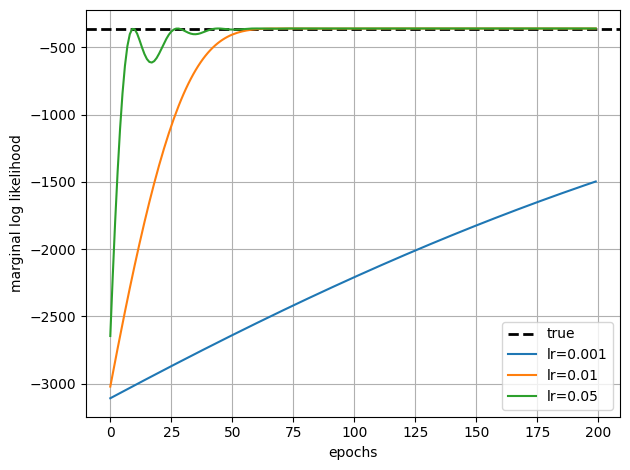

In [5]:
# Plot the SGD learning curves and the true marginal LL for comparison
true_ll = -float(neg_marginal_ll(jnp.array(rho_true)))
plt.axhline(true_ll, color="k", linestyle="--", lw=2, label="true")
for lr, lls in zip(learning_rates, all_sgd_marginal_lls):
    plt.plot(lls, "-", ms=4, label=f"lr={lr}")
plt.xlabel("epochs")
plt.ylabel("marginal log likelihood")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Fit with MCMC

We now use NumPyro's No-U-Turn Sampler (NUTS), an adaptive variant of Hamiltonian Monte Carlo, to approximate the posterior distribution over parameters,
$$p(\theta \mid y_{1:T}) \propto p(\theta)\, p(y_{1:T} \mid \theta),$$
where $p(y_{1:T} \mid \theta)$ is again the Kalman-filter marginal likelihood. Inside a NumPyro model we use `dsx.sample`, which registers that marginal likelihood as a factor, and `jax.grad` (used internally by NUTS) supplies the gradients.

In [6]:
def fully_bayesian_model(obs_times, obs_values):
    rho = numpyro.sample("rho", dist.Uniform(0.0, 1.5))
    with Filter(filter_config=KFConfig(filter_source="cuthbert")):
        dsx.sample("f", build_model(rho), obs_times=obs_times, obs_values=obs_values)


mcmc = MCMC(
    NUTS(fully_bayesian_model), num_warmup=200, num_samples=1000, progress_bar=False
)
mcmc.run(jr.PRNGKey(42), obs_times=obs_times, obs_values=emissions)
rho_samples = mcmc.get_samples()["rho"]
print(
    f"NUTS posterior: rho = {float(rho_samples.mean()):.4f} "
    f"± {float(rho_samples.std()):.4f}  (true {rho_true})"
)

NUTS posterior: rho = 0.9856 ± 0.0062  (true 0.99)


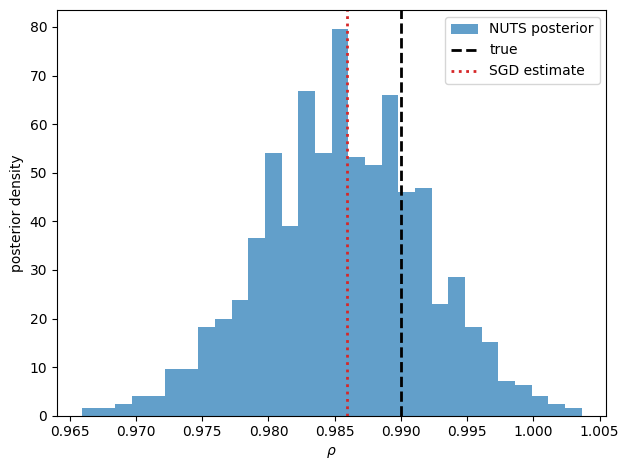

In [7]:
# Plot the posterior over rho, with the SGD estimate and true value for comparison
plt.hist(
    rho_samples,
    bins=30,
    density=True,
    alpha=0.7,
    color="tab:blue",
    label="NUTS posterior",
)
plt.axvline(rho_true, color="k", linestyle="--", lw=2, label="true")
plt.axvline(sgd_rho, color="tab:red", linestyle=":", lw=2, label="SGD estimate")
plt.xlabel(r"$\rho$")
plt.ylabel("posterior density")
plt.legend()
plt.tight_layout()
plt.show()

## Reconstructing and forecasting the emissions

Having estimated the parameters, we can use the model to smooth the observed emissions and to forecast future ones. Smoothing gives the posterior mean of the latent states, $\mu_{t\mid T}$, which we pass through the emission matrix to reconstruct the emissions, $\hat{y}_t = H\, \mu_{t\mid T}$, with variance $H \Sigma_{t\mid T} H^\top + R$. To forecast, we roll the model forward from the final smoothed state past the end of the data window; `Smoother` supports prediction at times at or after the last observation. Both use the SGD estimate of $\rho$.

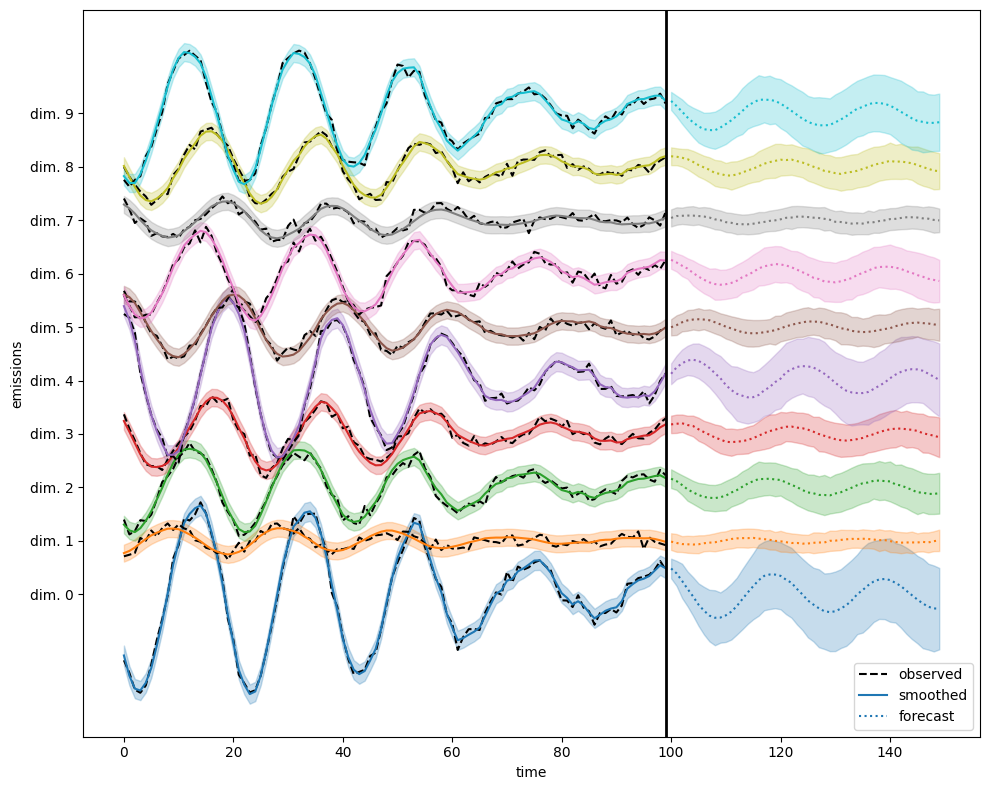

In [8]:
num_forecast = 50
future_times = jnp.arange(obs_times[-1] + 1.0, obs_times[-1] + 1.0 + num_forecast)

# Smooth the in-window emissions and roll the model forward past the data.
# n_simulations draws sample forecast trajectories from the final smoothed state.
n_rollout = 200
with DiscreteTimeSimulator(n_simulations=n_rollout):
    with Smoother(
        smoother_config=KFSmootherConfig(
            filter_source="cd_dynamax",
            record_smoothed_states_mean=True,
            record_smoothed_states_cov=True,
        )
    ):
        result = Predictive(lgssm_model, num_samples=1)(
            jr.PRNGKey(3),
            build_model(sgd_rho),
            obs_times=obs_times,
            obs_values=emissions,
            predict_times=future_times,
        )

# Smoothed (in-window) emission reconstruction and its standard deviation.
smoothed_mean = result["f_smoothed_states_mean"][0]  # (T, state_dim)
smoothed_cov = result["f_smoothed_states_cov"][0]  # (T, state_dim, state_dim)
smooth_emissions = smoothed_mean @ true_H.T
smooth_cov = true_H @ smoothed_cov @ true_H.T + true_R
smooth_std = jnp.sqrt(jnp.diagonal(smooth_cov, axis1=-2, axis2=-1))

# Forecast (out-of-window) emissions from the rollout trajectories.
forecast_obs = result["f_predicted_observations"][
    0
]  # (n_rollout, num_forecast, emission_dim)
forecast_emissions = forecast_obs.mean(axis=0)
forecast_std = forecast_obs.std(axis=0)

spc = 4
plt.figure(figsize=(10, 8))
for i in range(emission_dim):
    plt.plot(
        obs_times,
        emissions[:, i] + spc * i,
        "--k",
        label="observed" if i == 0 else None,
    )
    ln = plt.plot(
        obs_times,
        smooth_emissions[:, i] + spc * i,
        label="smoothed" if i == 0 else None,
    )[0]
    plt.fill_between(
        obs_times,
        spc * i + smooth_emissions[:, i] - 2 * smooth_std[:, i],
        spc * i + smooth_emissions[:, i] + 2 * smooth_std[:, i],
        color=ln.get_color(),
        alpha=0.25,
    )
    plt.plot(
        future_times,
        forecast_emissions[:, i] + spc * i,
        ls=":",
        c=ln.get_color(),
        label="forecast" if i == 0 else None,
    )
    plt.fill_between(
        future_times,
        spc * i + forecast_emissions[:, i] - 2 * forecast_std[:, i],
        spc * i + forecast_emissions[:, i] + 2 * forecast_std[:, i],
        color=ln.get_color(),
        alpha=0.25,
    )
plt.axvline(float(obs_times[-1]), color="black", lw=2)
plt.xlabel("time")
plt.ylabel("emissions")
plt.yticks(spc * jnp.arange(emission_dim), [f"dim. {i}" for i in range(emission_dim)])
plt.legend()
plt.tight_layout()
plt.show()

## Conclusion

This notebook showed two ways to fit a linear Gaussian state-space model in dynestyx:

- **SGD** on the negative marginal log likelihood, using `dsx.condition` (NumPyro-free) with any optax optimizer.
- **MCMC** for the Bayesian posterior, using `dsx.sample` inside a NumPyro model with NUTS.

Both use the same Kalman-filter marginal likelihood; the only difference is whether it is returned as a plain value (`dsx.condition`) or registered as a NumPyro factor (`dsx.sample`). The SGD point estimate lands inside the NUTS posterior, as expected for a well-identified parameter. Finally, with the fitted parameters we reconstructed the in-window emissions by smoothing and forecast future emissions by rolling the model forward from the final smoothed state.